In [1]:
data <- read.csv("IBM.csv")

In [2]:
head(data)

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
,<int>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>
1,41,Yes,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6
2,49,No,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10
3,37,Yes,Research & Development,2,2,Other,4,3,Single,2090,6,3,0
4,33,No,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8
5,27,No,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2
6,32,No,Research & Development,2,2,Life Sciences,4,4,Single,3068,0,2,7


In [3]:
dim(data)
names(data)
summary(data)

[1] 1470   13

[1] "Age"                     "Attrition"              
 [3] "Department"              "DistanceFromHome"       
 [5] "Education"               "EducationField"         
 [7] "EnvironmentSatisfaction" "JobSatisfaction"        
 [9] "MaritalStatus"           "MonthlyIncome"          
[11] "NumCompaniesWorked"      "WorkLifeBalance"        
[13] "YearsAtCompany"

      Age            Attrition        Department   DistanceFromHome
 Min.   :18.00   Length   :1470   Length   :1470   Min.   : 1.000  
 1st Qu.:30.00   N.unique :   2   N.unique :   3   1st Qu.: 2.000  
 Median :36.00   N.blank  :   0   N.blank  :   0   Median : 7.000  
 Mean   :36.92   Min.nchar:   2   Min.nchar:   5   Mean   : 9.193  
 3rd Qu.:43.00   Max.nchar:   3   Max.nchar:  22   3rd Qu.:14.000  
 Max.   :60.00                                     Max.   :29.000  
   Education       EducationField EnvironmentSatisfaction JobSatisfaction
 Min.   :1.000   Length   :1470   Min.   :1.000           Min.   :1.000  
 1st Qu.:2.000   N.unique :   6   1st Qu.:2.000           1st Qu.:2.000  
 Median :3.000   N.blank  :   0   Median :3.000           Median :3.000  
 Mean   :2.913   Min.nchar:   5   Mean   :2.722           Mean   :2.729  
 3rd Qu.:4.000   Max.nchar:  16   3rd Qu.:4.000           3rd Qu.:4.000  
 Max.   :5.000                    Max.   :4.000           Max.   :4.000  
   Mar

In [4]:
colSums(is.na(data))

Age               Attrition              Department 
                      0                       0                       0 
       DistanceFromHome               Education          EducationField 
                      0                       0                       0 
EnvironmentSatisfaction         JobSatisfaction           MaritalStatus 
                      0                       0                       0 
          MonthlyIncome      NumCompaniesWorked         WorkLifeBalance 
                      0                       0                       0 
         YearsAtCompany 
                      0

In [5]:
data$Age[is.na(data$Age)] <- mean(data$Age, na.rm = TRUE)
data$MonthlyIncome[is.na(data$MonthlyIncome)] <- mean(data$MonthlyIncome, na.rm = TRUE)

In [6]:
data$DistanceFromHome[is.na(data$DistanceFromHome)] <- median(data$DistanceFromHome, na.rm = TRUE)

In [7]:
mode_attrition <- names(sort(table(data$Attrition), decreasing = TRUE))[1]
data$Attrition[is.na(data$Attrition)] <- mode_attrition

In [9]:
library(ggplot2)
library(corrplot)

corrplot 0.95 loaded



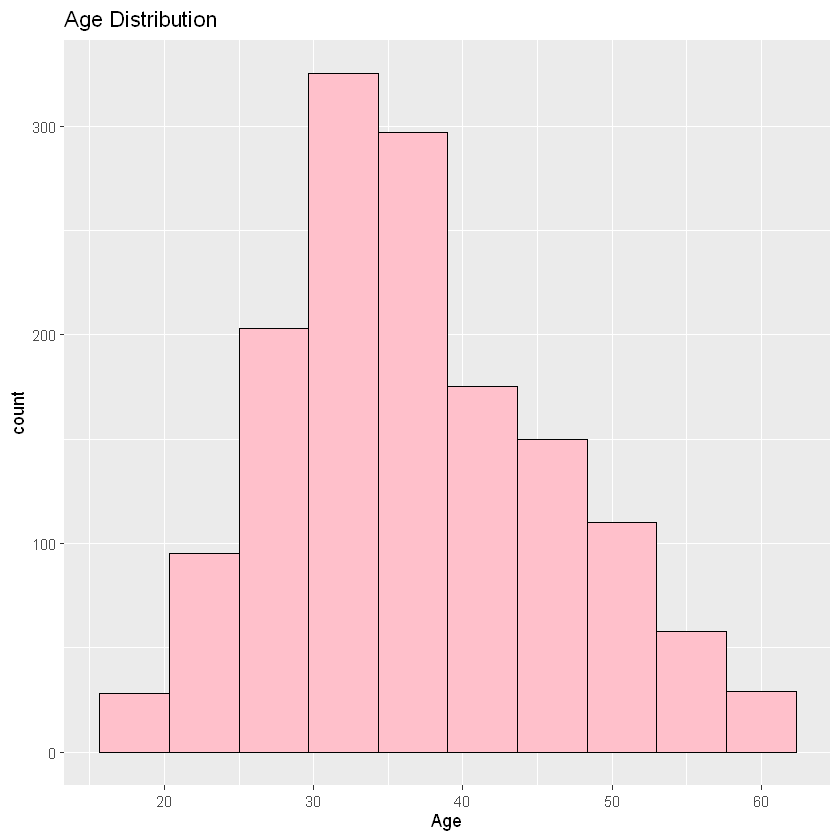

In [17]:
ggplot(data, aes(x = Age)) +geom_histogram(fill = "pink", color = "black", bins = 10) +ggtitle("Age Distribution")

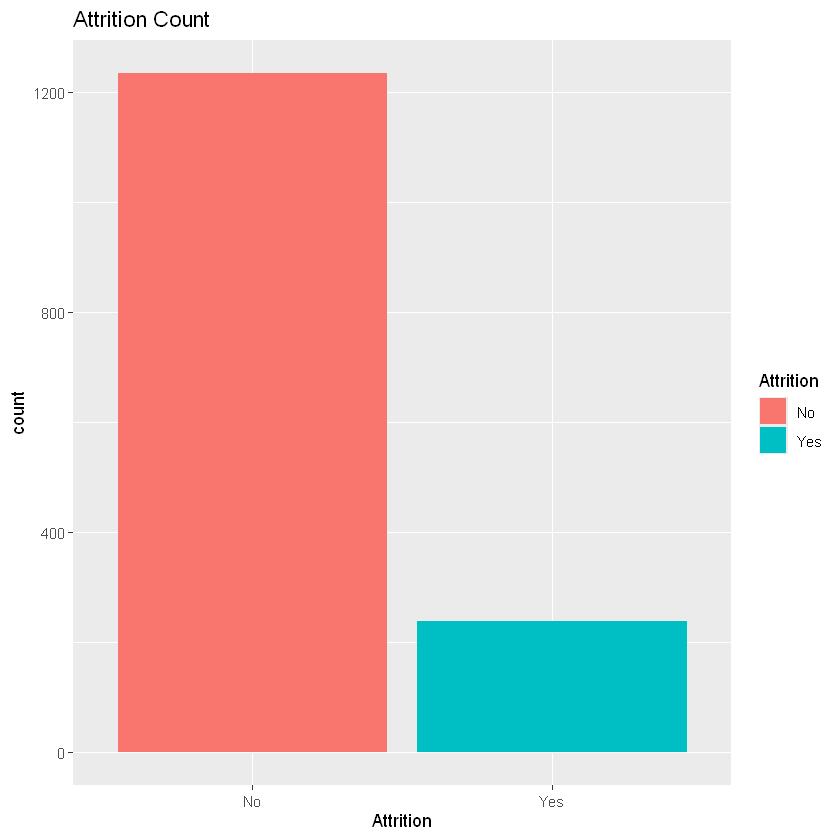

In [16]:
ggplot(data, aes(x = Attrition, fill = Attrition)) +geom_bar() +ggtitle("Attrition Count")

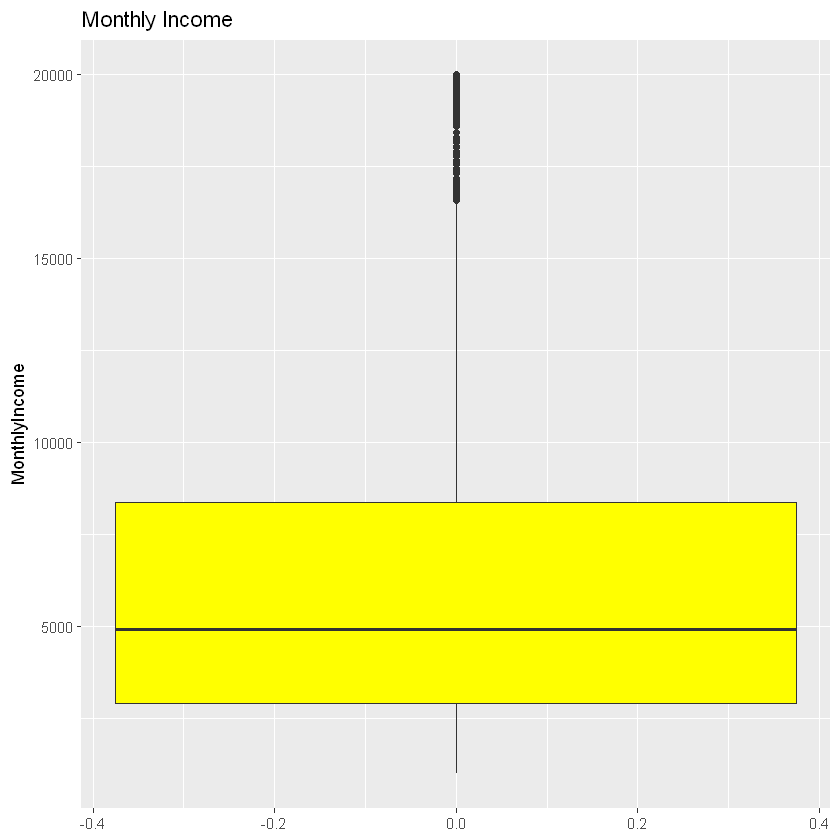

In [15]:
ggplot(data, aes(y = MonthlyIncome)) +geom_boxplot(fill = "yellow") +ggtitle("Monthly Income")

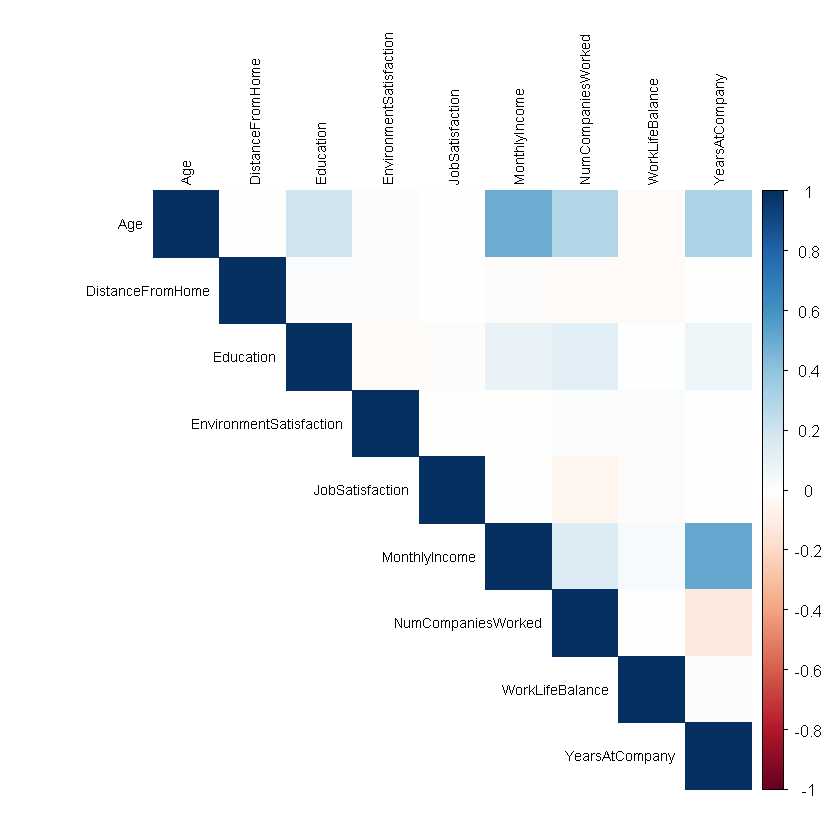

In [14]:
num_data <- data[sapply(data, is.numeric)]
cor_matrix <- cor(num_data)
corrplot(cor_matrix,method = "color",type = "upper",tl.col = "black",tl.cex = 0.7)